# Analysis of the COLIBRE ellipticity profiles

In [120]:
import numpy as np
import dill

from matplotlib import pyplot as plt

# Use TeX
from matplotlib import rc
rc('font', size=18)
rc('text', usetex=True)
rc('font', family='serif')

from scipy.optimize import curve_fit

#from astropy import units as u
#from astropy.constants import G, c
#from astropy.cosmology import Planck18 as cosmo

# 1. Data

In [277]:
# Load the file

with open("kw_psi_r.dll","rb") as f:
   data = dill.load(f)

qs       = data['q'] # axis ratio
zeta_REs = data['xi_RE'] # elliptical radius divided by Einstein radius
REs      = data['RE'] # Einstein radius in kpc
dPAs     = data['dPA'] # Pointing angle of ellipticity (with reference at theta_E) 


# Remove lenses that lead to problematic fits afterwards.
# This is a bit of cherry picking but I'm only removing 5 out of 120 here, which is not the end of the world

bad_fits = [4, 34, 49, 92, 93]

for i, bad in enumerate(bad_fits):
    del qs[bad - i]
    del zeta_REs[bad - i]
    del REs[bad - i]
    del dPAs[bad - i]

# 2. Axis ratio as a function of radius

## Plots

Axis ratio as a function of the elliptical radius $\zeta$, normalised by the Einstein radius $\theta_{\rm E}$.

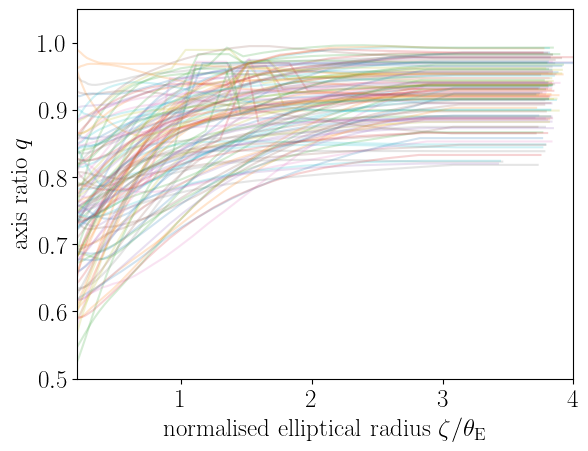

In [122]:
for lens, q in enumerate(qs):
    zeta_RE = zeta_REs[lens]
    plt.plot(zeta_RE, q, alpha=0.2)

plt.ylabel(r"axis ratio $q$")
plt.xlabel(r"normalised elliptical radius $\zeta/\theta_{\rm E}$")
plt.xlim([0.2, 4])
plt.ylim([0.5, 1.05])

plt.show();

Axis ratio as a function of the physical elliptical radius $\zeta$

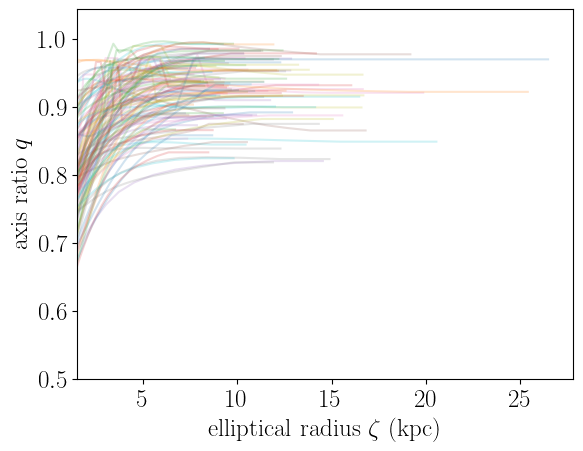

In [123]:
for lens, q in enumerate(qs):
    zeta_RE = zeta_REs[lens]
    RE = REs[lens]
    zeta = zeta_RE * RE
    plt.plot(zeta, q, alpha=0.2)

plt.ylabel(r"axis ratio $q$")
plt.xlabel(r"elliptical radius $\zeta$ (kpc)")
plt.xlim(left=1.5)
plt.ylim(bottom=0.5)

plt.show();

## Modelling

I tried the following models and indicated those that work and those that do not work. The rest of this section focuses on the successful $\tanh$ model.

In [124]:
def q_model(R, a, b, c):
    "Does not work"
    return (a + R**c) / (b + R**c)

def q_model(R, a, b, c):
    "Works very well"
    return a * (1 - b * np.exp(-c * R))

def q_model(R, a, b, c):
    "Works very well"
    return a * np.tanh(b * (R+c))

def q_model(R, q_inf, R0, DR):
    "Reparameterisation of the previous one."
    return q_inf * np.tanh((R + R0) / DR)

Example on one lens.

q_inf, R0, DR = [0.90094755 0.44030226 0.01052463]


/var/folders/fc/8ml2gs_91pd0cfcp6dyg98kc0000gn/T/ipykernel_51441/3946038084.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(q_model, zeta_RE, q)


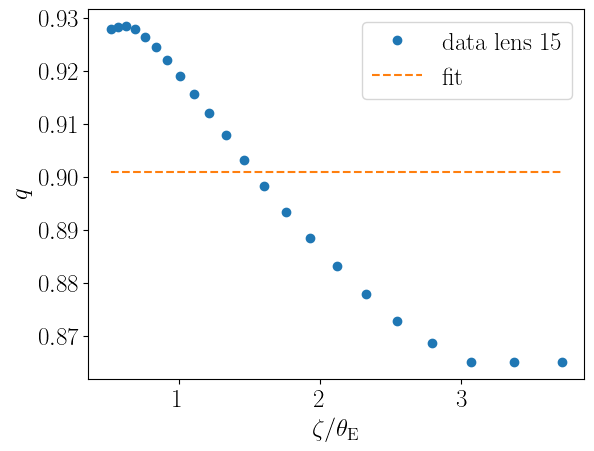

In [125]:
lens = 15
z_min = 0.5 # minimal zeta/RE for the fit

z = zeta_REs[lens]
zeta_RE = z[z>z_min] # cut the profile below zeta/rE > R_min
q = qs[lens][-len(zeta_RE):]

# make fit
popt, pcov = curve_fit(q_model, zeta_RE, q)
print("q_inf, R0, DR =", popt)

plt.plot(zeta_RE, q, 'o', label="data lens {}".format(lens))
plt.plot(zeta_RE, q_model(zeta_RE, *popt), '--', label=r"fit")

plt.xlabel(r"$\zeta/\theta_{\rm E}$")
plt.ylabel(r"$q$")
plt.legend()
plt.show();

Fit all the lenses and display the statistics of parameters.

In [19]:
q_inf, R0, DR = np.array([]), np.array([]), np.array([])

for lens, z in enumerate(zeta_REs):
    zeta_RE = z[z>z_min] # cut the profile below R_min
    q = qs[lens][-len(zeta_RE):]

    # make fit
    popt, pcov = curve_fit(q_model, zeta_RE, q, bounds=([0, -10, 0.1], [1, 10, 10]))

    q_inf = np.append(q_inf, popt[0])
    R0 = np.append(R0, popt[1])
    DR = np.append(DR, popt[2])

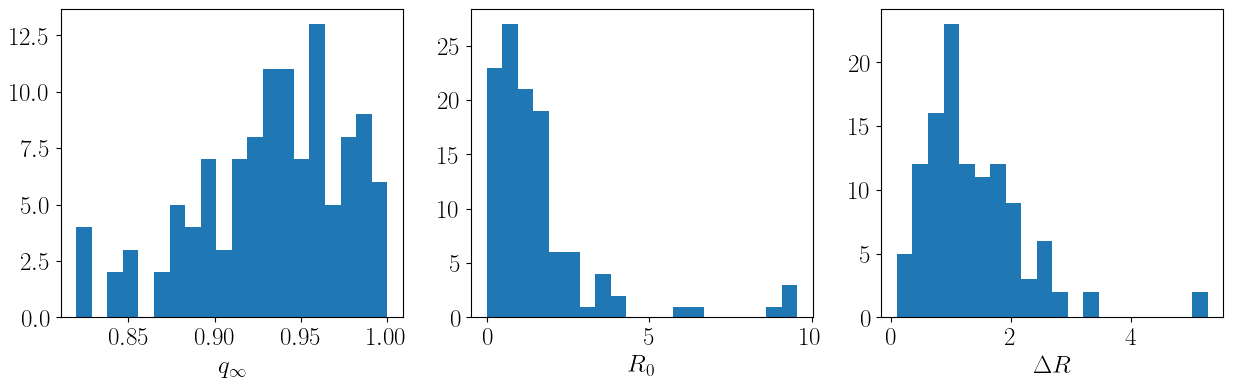

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax=axes[0]
ax.hist(q_inf, bins=20)
ax.set_xlabel(r'$q_\infty$')

ax=axes[1]
ax.hist(R0, bins=20)
ax.set_xlabel(r'$R_0$')

ax=axes[2]
ax.hist(DR, bins=20)
ax.set_xlabel(r'$\Delta R$')

plt.show()

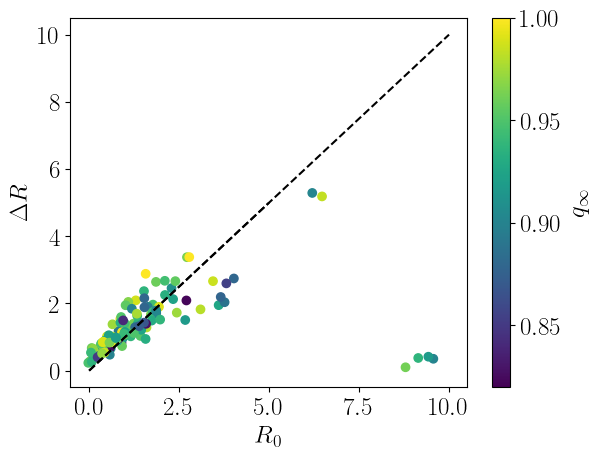

In [22]:
fig, ax = plt.subplots()

scatter = ax.scatter(R0, DR, c=q_inf)
fig.colorbar(scatter, ax=ax, label=r'$q_\infty$')

ax.plot([0, 10], [0, 10], 'k--')

ax.plot([0, 5], [0, 5], 'k--')

ax.set_xlabel(r'$R_0$')
ax.set_ylabel(r'$\Delta R$')

plt.show()

### Repeat the same with the physical elliptical radius

In [24]:
def q_model(zeta, q_inf, zeta0, Dzeta):
    return q_inf * np.tanh((zeta + zeta0) / Dzeta)

zeta_min = 1.5 # minimum physical radius in kpc, corresponds roughly to the softening length of COLIBRE
q_inf, zeta0, Dzeta = np.array([]), np.array([]), np.array([]) # list of best-fit parameters

for lens, RE in enumerate(REs):

    zeta_RE = zeta_REs[lens]
    zeta_ = R * RE
    zeta = zeta_[zeta_>zeta_min] # cut the profile below zeta_min
    q = qs[lens][-len(zeta):]

    # make fit
    popt, pcov = curve_fit(q_model, zeta, q, bounds=([0, -50, 0.1], [1, 50, 100]))
    
    q_inf = np.append(q_inf, popt[0])
    zeta0 = np.append(zeta0, popt[1])
    Dzeta = np.append(Dzeta, popt[2])

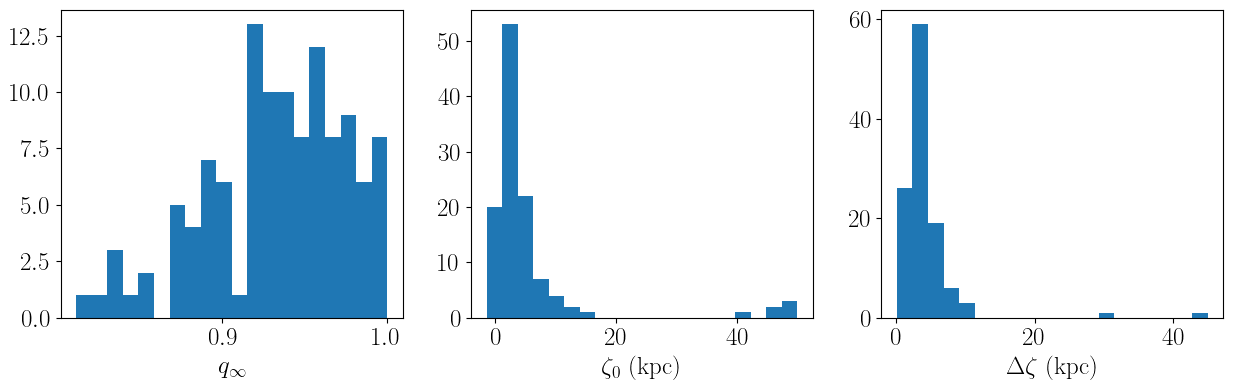

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax=axes[0]
ax.hist(q_inf, bins=20)
ax.set_xlabel(r'$q_\infty$')

ax=axes[1]
ax.hist(zeta0, bins=20)
ax.set_xlabel(r'$\zeta_0$ (kpc)')

ax=axes[2]
ax.hist(Dzeta, bins=20)
ax.set_xlabel(r'$\Delta \zeta$ (kpc)')

plt.show()

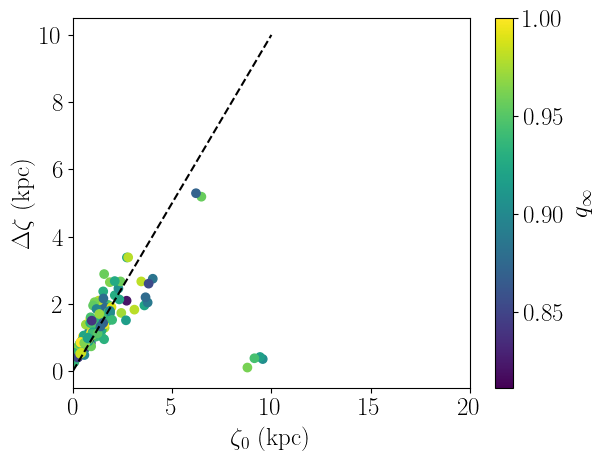

In [27]:
fig, ax = plt.subplots()

scatter = ax.scatter(R0, DR, c=q_inf)
fig.colorbar(scatter, ax=ax, label=r'$q_\infty$')

ax.plot([0, 10], [0, 10], 'k--')

ax.set_xlabel(r'$\zeta_0$ (kpc)')
ax.set_ylabel(r'$\Delta \zeta$ (kpc)')

ax.set_xlim([0, 20])

plt.show()

This is quite similar to the previous results.

## 3. Ellipticity as a function of radius

Try the ellipticity instead of the axis ratio to see whether a simpler model can be found.

In [106]:
ellipticities = [0.5 * (1/q - q) for q in qs]

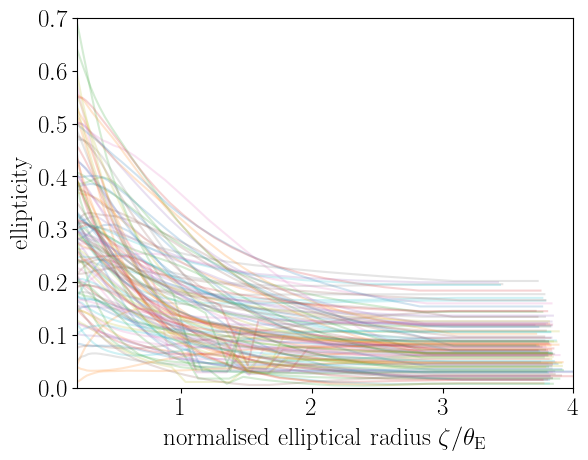

In [294]:
for lens, ellipticity in enumerate(ellipticities):
    zeta_RE = zeta_REs[lens]
    plt.plot(zeta_RE, ellipticity, alpha=0.2)

plt.ylabel(r"ellipticity")
plt.xlabel(r"normalised elliptical radius $\zeta/\theta_{\rm E}$")
plt.xlim([0.2, 4])
plt.ylim([0, 0.7])

plt.savefig('e_zeta.pdf', bbox_inches='tight')
plt.show();

## Modelling

In [196]:
def e_model(z, a, b, c, d):
    """
    Works well but not as much as the next one.
    """
    e = a + b / (c + z**d)
    return e


def e_model(z, e_inf, e_E, Dz):
    """
    Works very well.
    """
    e = e_inf + (e_E - e_inf) * np.exp(-(z-1)/Dz)
    return e

$$
e(\zeta) = e_\infty + (e_{\rm E} - e_\infty) \, \exp\left(- \frac{\zeta - \theta_{\rm E}}{\Delta \zeta} \right)
$$

e_inf, e_E, Dz = [0.05643343 0.176038   0.96844349]


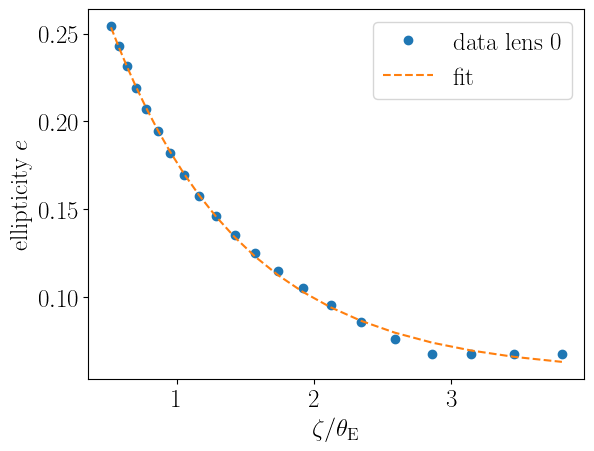

In [292]:
lens = 0
z_min = 0.5 # minimal zeta/RE for the fit

z = zeta_REs[lens]
zeta_RE = z[z>z_min] # cut the profile below zeta/rE > R_min
ellipticity = ellipticities[lens][-len(zeta_RE):]

# make fit
popt, pcov = curve_fit(e_model, zeta_RE, ellipticity)
print("e_inf, e_E, Dz =", popt)

plt.plot(zeta_RE, ellipticity, 'o', label="data lens {}".format(lens))
plt.plot(zeta_RE, e_model(zeta_RE, *popt), '--', label=r"fit")

plt.xlabel(r"$\zeta/\theta_{\rm E}$")
plt.ylabel(r"ellipticity $e$")
plt.legend()
plt.show();

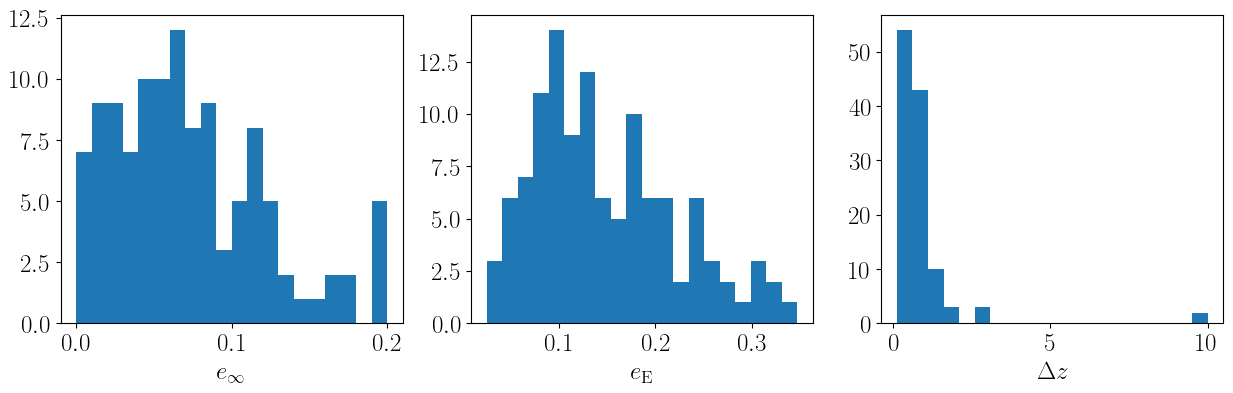

In [296]:
e_inf, e_E, Dz = np.array([]), np.array([]), np.array([])

for lens, z in enumerate(zeta_REs):
    zeta_RE = z[z>z_min] # cut the profile below R_min
    ellipticity = ellipticities[lens][-len(zeta_RE):]

    # make fit
    popt, pcov = curve_fit(e_model, zeta_RE, ellipticity, bounds=([0, 0, 0.1], [1, 1, 10]))

    e_inf = np.append(e_inf, popt[0])
    e_E = np.append(e_E, popt[1])
    Dz = np.append(Dz, popt[2])


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax=axes[0]
ax.hist(e_inf, bins=20)
ax.set_xlabel(r'$e_\infty$')

ax=axes[1]
ax.hist(e_E, bins=20)
ax.set_xlabel(r'$e_{\rm E}$')

ax=axes[2]
ax.hist(Dz, bins=20)
ax.set_xlabel(r'$\Delta z$')

plt.savefig('ellipticity_parameters.pdf', bbox_inches='tight')
plt.show()

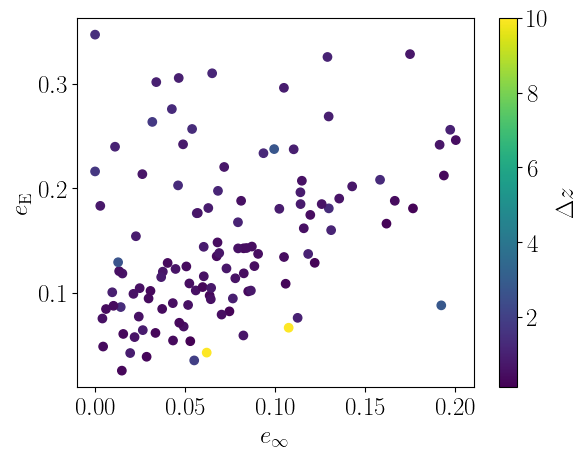

In [105]:
fig, ax = plt.subplots()

scatter = ax.scatter(e_inf, e_E, c=Dz)
fig.colorbar(scatter, ax=ax, label=r'$\Delta z$')

#ax.plot([0, 10], [0, 10], 'k--')

ax.set_xlabel(r'$e_\infty$')
ax.set_ylabel(r'$e_{\rm E}$')

#ax.set_xlim([0, 20])

plt.show()

Some crazy stuff.

e_inf, e_E, Dz = [ 0.10656489 -0.91336271  1.06200479 -0.31884     3.72414774  3.9811233 ]


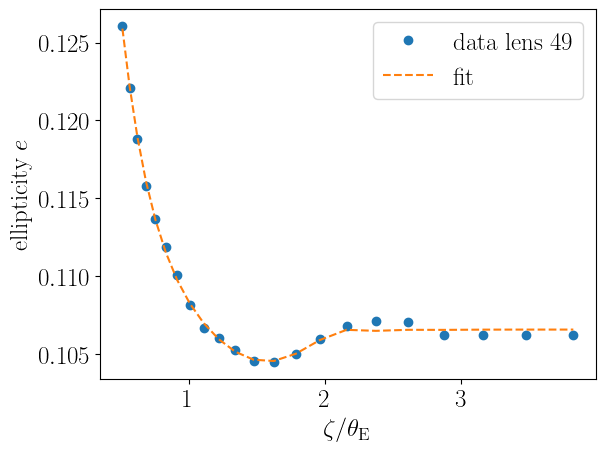

In [205]:
def e_model_crazy(z, a, b, c, d, f, g):
    e = a + (b + c * np.cos(d*(z)**f)) * np.exp(- g * z)
    return e

lens = 49
z_min = 0.5 # minimal zeta/RE for the fit

z = zeta_REs[lens]
zeta_RE = z[z>z_min] # cut the profile below zeta/rE > R_min
ellipticity = ellipticities[lens][-len(zeta_RE):]

# make fit
popt, pcov = curve_fit(e_model_crazy, zeta_RE, ellipticity)
print("e_inf, e_E, Dz =", popt)

plt.plot(zeta_RE, ellipticity, 'o', label="data lens {}".format(lens))
plt.plot(zeta_RE, e_model_crazy(zeta_RE, *popt), '--', label=r"fit")

plt.xlabel(r"$\zeta/\theta_{\rm E}$")
plt.ylabel(r"ellipticity $e$")
plt.legend()
plt.show();

## Logarithmic ellipticity?

In [48]:
epsilon = [-np.log(q) for q in qs]

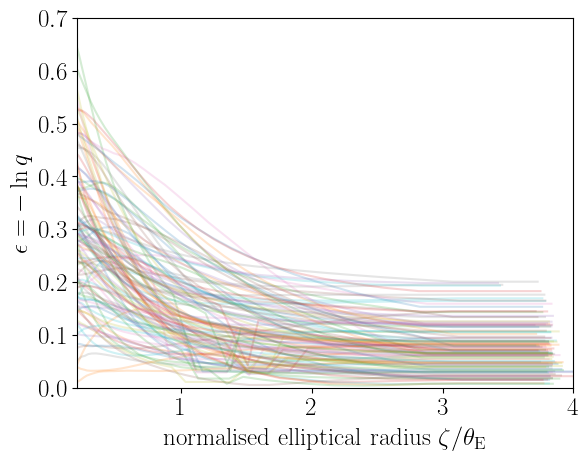

In [207]:
for lens, eps in enumerate(epsilon):
    zeta_RE = zeta_REs[lens]
    plt.plot(zeta_RE, eps, alpha=0.2)

plt.ylabel(r"$\epsilon = -\ln q$")
plt.xlabel(r"normalised elliptical radius $\zeta/\theta_{\rm E}$")
plt.xlim([0.2, 4])
plt.ylim([0, 0.7])

plt.show();

# 4. Pointing angle

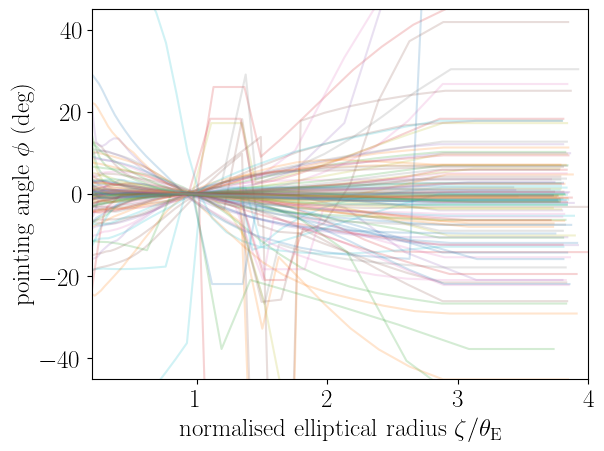

In [275]:
for lens, dPA in enumerate(dPAs):
    zeta_RE = zeta_REs[lens]
    plt.plot(zeta_RE, dPA, alpha=0.2)

plt.ylabel(r"pointing angle $\phi$ (deg)")
plt.xlabel(r"normalised elliptical radius $\zeta/\theta_{\rm E}$")
plt.xlim([0.2, 4])
plt.ylim([-45, 45])

plt.show();

In [283]:
def phi_model(z, Dphi, Dz, z0):
    phi = Dphi * (np.arctan((z - z0)/Dz) - np.arctan((1 - z0)/Dz))
    return phi

Dphi, Dz, z0 = [6.23998341 0.36889854 0.62010876]


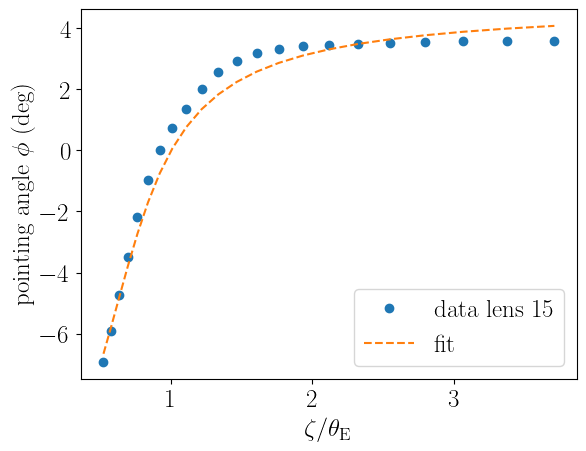

In [291]:
lens = 15
z_min = 0.5 # minimal zeta/RE for the fit

z = zeta_REs[lens]
zeta_RE = z[z>z_min] # cut the profile below zeta/rE > R_min
dPA = dPAs[lens][-len(zeta_RE):]

# make fit
popt, pcov = curve_fit(phi_model, zeta_RE, dPA)
print("Dphi, Dz, z0 =", popt)

plt.plot(zeta_RE, dPA, 'o', label="data lens {}".format(lens))
plt.plot(zeta_RE, phi_model(zeta_RE, *popt), '--', label=r"fit")

plt.xlabel(r"$\zeta/\theta_{\rm E}$")
plt.ylabel(r"pointing angle $\phi$ (deg)")
plt.legend()
plt.show();

In [278]:
Dphi, Dz, z0 = np.array([]), np.array([]), np.array([])

for lens, z in enumerate(zeta_REs):
    zeta_RE = z[z>z_min] # cut the profile below R_min
    dPA = dPAs[lens][-len(zeta_RE):]

    # make fit
    popt, pcov = curve_fit(phi_model, zeta_RE, dPA)

    Dphi = np.append(Dphi, popt[0])
    Dz = np.append(Dz, popt[1])
    z0 = np.append(z0, popt[2])

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

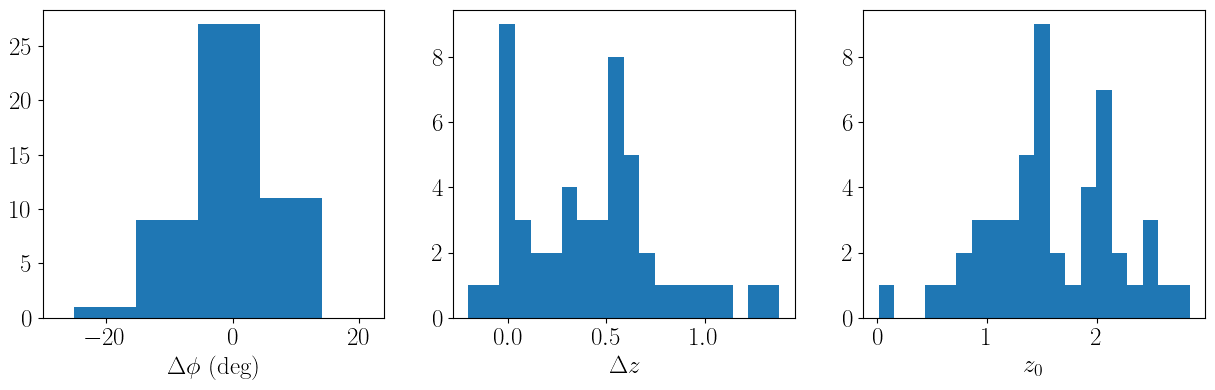

In [280]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax=axes[0]
ax.hist(Dphi, bins=20)
ax.set_xlabel(r'$\Delta\phi$ (deg)')
ax.set_xlim(left=-30)

ax=axes[1]
ax.hist(Dz, bins=20)
ax.set_xlabel(r'$\Delta z$')

ax=axes[2]
ax.hist(z0, bins=20)
ax.set_xlabel(r'$z_0$')

plt.show()